In [14]:
import numpy as np
import scipy.linalg
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import RealAmplitudes
from qiskit_aer.primitives import EstimatorV2
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# 1. SCALABLE PARAMETERS
# Define your Matrix A (Must be square)
A = np.array([[-1.0, 3], 
              [0.5, -1.0]]) 

x0 = np.array([1.0, 3.0]) # Initial condition vector
x0 = x0 / np.linalg.norm(x0)  # Normalize initial condition

b = np.array([0.0, 0.0]) # Right-hand side vector (for inhomogeneous equations)



p = 0 # Number of additional dummy time steps to boost the success probability of the algorithm
h = 0.1                # Time step
num_time_steps = 4   #  time steps
taylor_terms = 2      #  




# Determine system dimensions
dim_sys = A.shape[0]
dim_total = (num_time_steps+p) * taylor_terms * dim_sys
num_qubits = int(np.ceil(np.log2(dim_total)))
dim_total = 2**num_qubits  # Adjusted dimension to nearest power of 2
print(f"System requires {num_qubits} qubits for a {dim_total}x{dim_total} operator.")

System requires 4 qubits for a 16x16 operator.


In [15]:
import numpy as np
import scipy.linalg

def build_system_matrix_L(m, k, p, A, h):
    d = A.shape[0]

    # 1. Correct Dimensions
    dim_j = k           # Math: for k=3, it's a 4x4 block matrix
    dim_i = m + p       # Math: N^{m+p+1} = 0 implies dimension is m+p+1
    
    I_sys = np.eye(d)
    
    # 2. M1 Matrix
    M1 = np.zeros((dim_j * d, dim_j * d), dtype=complex)
    for j in range(k-1):     # Math: sum j=0 to k-1
        shift_j = np.zeros((dim_j, dim_j))
        shift_j[j+1, j] = 1
        M1 += np.kron(shift_j, (A * h) / (j + 1))
        
    # 3. M2 Matrix
    M2 = np.zeros((dim_j * d, dim_j * d), dtype=complex)
    for j in range(k): # Math: sum j=0 to k-1
        proj_j = np.zeros((dim_j, dim_j))
        proj_j[0, j] = 1
        M2 += np.kron(proj_j, I_sys)
        
    # 4. N Matrix
    I_M1_inv = scipy.linalg.inv(np.eye(dim_j * d) - M1)
    block_1 = M2 @ I_M1_inv
    I_j_sys = np.eye(dim_j * d)
    
    N = np.zeros((dim_i * dim_j * d, dim_i * dim_j * d), dtype=complex)
    
    # First sum of N (Eq 4.9): i = 0 to m.
    # Capped at dim_i - 1 to safely handle the math contradiction when p=0
    limit_1 = min(m , dim_i - 1)
    for i in range(limit_1):
        shift_i = np.zeros((dim_i, dim_i))
        shift_i[i+1, i] = 1
        N += np.kron(shift_i, block_1)
        
    # Second sum of N (Eq 4.9): i = m+1 to m+p-1
    # In Python, exclusive upper bound means we use m+p
    for i in range(m , m + p-1): 
        shift_i = np.zeros((dim_i, dim_i))
        shift_i[i+1, i] = 1
        N += np.kron(shift_i, I_j_sys)
        
    return np.eye(dim_i * dim_j * d) - N


def pad_to_power_of_2(L):
    """Pads a square matrix L with Identity to the next power of 2."""
    D = L.shape[0]
    
    # Calculate the next power of 2
    next_power_of_2 = 1 << (D - 1).bit_length() if D > 1 else 1
    
    # If it's already a power of 2, just return it
    if D == next_power_of_2:
        return L
    
    # Create an Identity matrix of the target size
    # Make sure to match the dtype of your original matrix (complex)
    L_padded = np.eye(next_power_of_2, dtype=L.dtype)
    
    # Insert the original L matrix into the top-left corner
    L_padded[:D, :D] = L
    
    return L_padded
L = build_system_matrix_L(num_time_steps, taylor_terms, p, A, h)
#L = build_system_matrix_L(4,2,2,A,h)
L = pad_to_power_of_2(L)  # Pad L to nearest power of 2
print(f"Padded L to dimension {L.shape[0]} for {num_qubits} qubits.")


Padded L to dimension 16 for 4 qubits.


In [16]:
import numpy as np

def build_initial_state(m, k, p, x0, h, dim, b=None):
    """
    Constructs the unnormalized initial state |psi_in> for the ODE QLSA,
    padded with zeros to match a target power-of-2 dimension.
    """
    # Ensure x0 is a flat complex array
    x0 = np.array(x0, dtype=complex).flatten()
    d = len(x0)
    
    # Handle the homogeneous case where b is not provided (b = 0)
    if b is None:
        b = np.zeros(d, dtype=complex)
    else:
        b = np.array(b, dtype=complex).flatten()
        
    # Dimensions based on the corrected L matrix mathematical structure
    dim_i = m + p 
    dim_j = k 
    
    # The mathematical dimension before padding
    original_dim = dim_i * dim_j * d
    
    # Initialize the unpadded statevector
    psi_in = np.zeros(original_dim, dtype=complex)
    
    # --- 1. Construct the first term: |0, 0, x_0> ---
    i_0 = np.zeros(dim_i)
    i_0[0] = 1
    
    j_0 = np.zeros(dim_j)
    j_0[0] = 1
    
    psi_in += np.kron(i_0, np.kron(j_0, x0))
    
    # --- 2. Construct the summation term: h * sum |i, 1, b> ---
    j_1 = np.zeros(dim_j)
    if dim_j > 1: 
        j_1[1] = 1
        
    for i in range(m-1):
        i_state = np.zeros(dim_i)
        i_state[i] = 1
        psi_in += h * np.kron(i_state, np.kron(j_1, b))
        
    # --- 3. Pad with zeros to match the target 'dim' ---
    if dim < original_dim:
        raise ValueError(f"Target dimension 'dim' ({dim}) must be >= original dimension ({original_dim})")
        
    psi_in_padded = np.zeros(dim, dtype=complex)
    psi_in_padded[:original_dim] = psi_in
    
    return psi_in_padded



psi_in = build_initial_state(num_time_steps, taylor_terms, p, x0, h, 2**num_qubits, b=b)

# Normalize
psi_in_norm = psi_in / np.linalg.norm(psi_in)
psi_proj_matrix = np.outer(psi_in_norm, psi_in_norm)

# 5. Convert to Pauli Operators (Scalable conversion)
L_pauli = SparsePauliOp.from_operator(L)
psi_proj_pauli = SparsePauliOp.from_operator(psi_proj_matrix)

num_op = L_pauli.adjoint() @ psi_proj_pauli @ L_pauli
den_op = L_pauli.adjoint() @ L_pauli


In [20]:
# 6. Initialize Estimator and Ansatz
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorEstimator # Fast local V2 simulator
beckend = AerSimulator()
from qiskit import transpile # <-- Add this import
# RealAmplitudes is a standard, scalable circuit
ansatz = RealAmplitudes(num_qubits, reps=3, entanglement='full')
cost_history = []


ansatz = RealAmplitudes(num_qubits, reps=3, entanglement='full')
backend = AerSimulator()


isa_ansatz = transpile(ansatz, backend=backend)

# 3. Initialize the V2 Estimator
estimator = StatevectorEstimator()
cost_history = []

def vqls_cost(theta):
    # 4. Use V2 PUBs to pass parameters directly!
    # Format: (circuit, observable, parameter_values)
    pubs = [
        (isa_ansatz, num_op, theta), 
        (isa_ansatz, den_op, theta)
    ]
    
    # 5. Execute
    results = estimator.run(pubs).result()
    
    # Extract values (casting to float prevents NumPy array shape errors later)
    num_val = float(results[0].data.evs)
    den_val = float(results[1].data.evs)
    
    # Calculate Cost
    cost = 1.0 - (num_val / den_val)
    cost_history.append(cost)
    
    if len(cost_history) % 200 == 0:
        print(f"Iteration {len(cost_history)} | Cost: {cost:.6f}")
        
    return cost

# 6. Optimization
initial_theta = np.random.rand(ansatz.num_parameters) * np.pi
print("Optimizing VQLS...")

res = minimize(
    vqls_cost, 
    initial_theta, 
    method='COBYLA', 
    options={'maxiter': 10000}, 
    tol=0.00001
)
print(f"Final Cost: {res.fun:.8f}")

C:\Users\souce\AppData\Local\Temp\ipykernel_34180\3909537244.py:7: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits, reps=3, entanglement='full')
C:\Users\souce\AppData\Local\Temp\ipykernel_34180\3909537244.py:11: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits, reps=3, entanglement='full')


Optimizing VQLS...
Iteration 200 | Cost: 0.049748
Iteration 400 | Cost: 0.008825
Iteration 600 | Cost: 0.004208
Iteration 800 | Cost: 0.002430
Iteration 1000 | Cost: 0.001509
Iteration 1200 | Cost: 0.001044
Iteration 1400 | Cost: 0.000811
Iteration 1600 | Cost: 0.000680
Iteration 1800 | Cost: 0.000578
Iteration 2000 | Cost: 0.000513
Iteration 2200 | Cost: 0.000460
Iteration 2400 | Cost: 0.000419
Iteration 2600 | Cost: 0.000370
Iteration 2800 | Cost: 0.000329
Iteration 3000 | Cost: 0.000282
Iteration 3200 | Cost: 0.000256
Iteration 3400 | Cost: 0.000229
Iteration 3600 | Cost: 0.000202
Iteration 3800 | Cost: 0.000184
Iteration 4000 | Cost: 0.000161
Iteration 4200 | Cost: 0.000144
Iteration 4400 | Cost: 0.000129
Iteration 4600 | Cost: 0.000117
Iteration 4800 | Cost: 0.000104
Iteration 5000 | Cost: 0.000090
Iteration 5200 | Cost: 0.000079
Iteration 5400 | Cost: 0.000071
Iteration 5600 | Cost: 0.000064
Iteration 5800 | Cost: 0.000057
Iteration 6000 | Cost: 0.000051
Iteration 6200 | Cost: 0.

(16,) 16


C:\Users\souce\AppData\Local\Temp\ipykernel_34180\3666853044.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  classical_probs[:dim_total] = classical_data


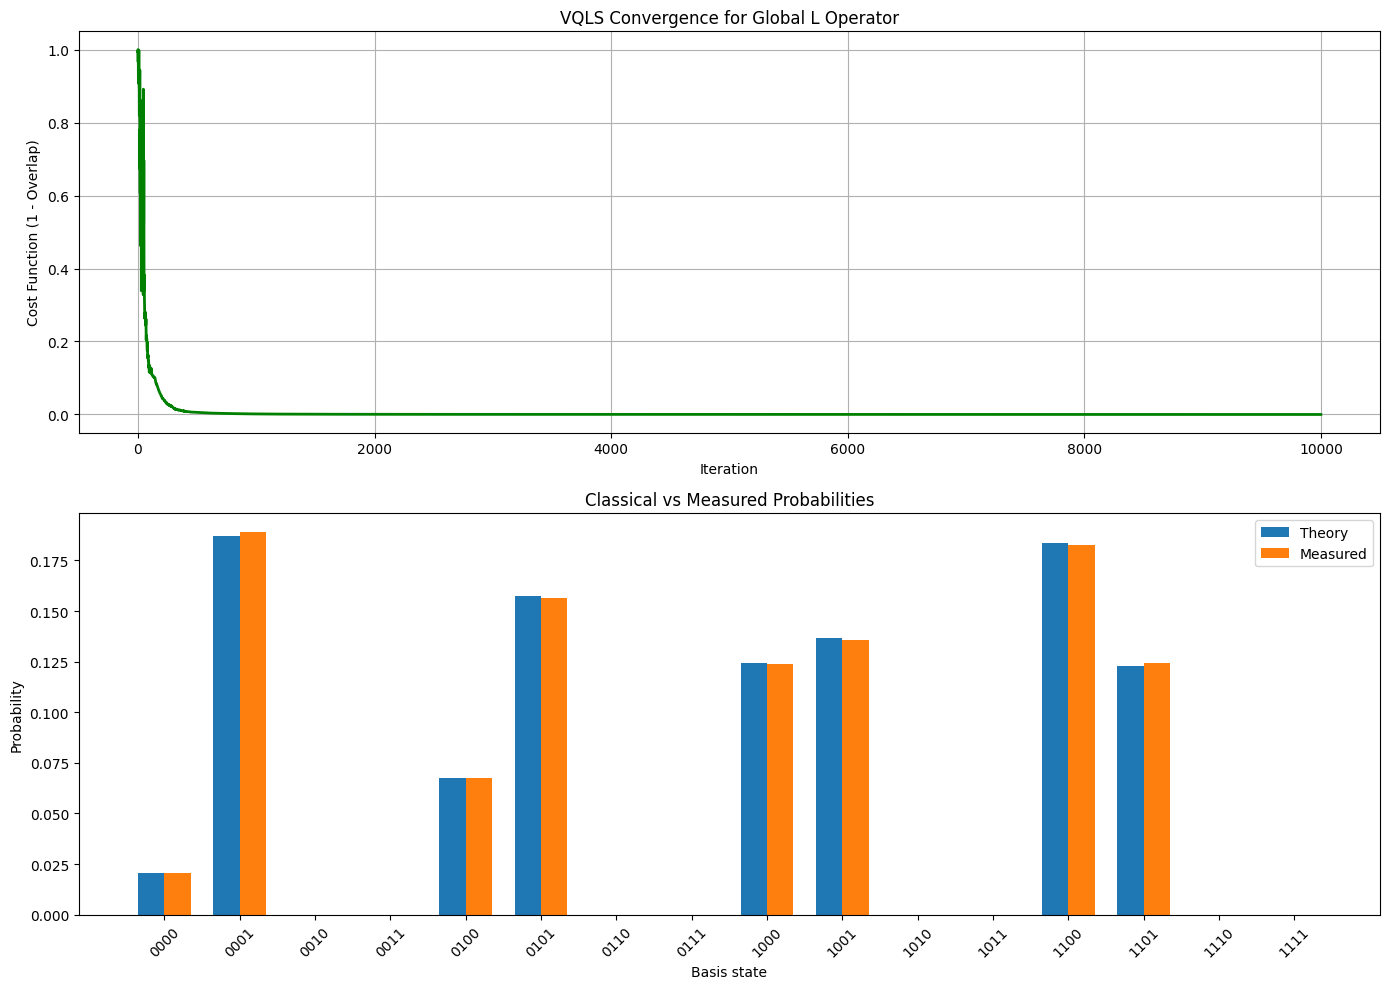

In [21]:
# 8. Compare Results
opt_qc = ansatz.assign_parameters(res.x)
opt_qc.measure_all()
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile

simulator = AerSimulator(shots=100000)
compiled = transpile(opt_qc, simulator).decompose()
job = simulator.run(compiled)
result = job.result()
classical_data = scipy.linalg.inv(L) @ psi_in
classical_data = classical_data / scipy.linalg.norm(classical_data)
classical_data = classical_data**2


counts = result.get_counts(compiled)

measured_probs = np.zeros(2**num_qubits)
print(measured_probs.shape, dim_total)
for bitstr, count in counts.items():
    measured_probs[int(bitstr, 2)] = count / sum(counts.values())

classical_probs = np.zeros_like(measured_probs)
classical_probs[:dim_total] = classical_data


labels = [format(i, f'0{num_qubits}b') for i in range(2**num_qubits)]
x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(cost_history, color='green', linewidth=2)
ax1.set_title('VQLS Convergence for Global L Operator')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Cost Function (1 - Overlap)')
ax1.grid(True)

ax2.bar(x - width / 2, classical_probs, width, label='Theory')
ax2.bar(x + width / 2, measured_probs, width, label='Measured')

ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45)
ax2.set_xlabel('Basis state')
ax2.set_ylabel('Probability')
ax2.set_title('Classical vs Measured Probabilities')
ax2.legend()



plt.tight_layout()
plt.show()



In [19]:
import numpy as np
from scipy.linalg import expm

def compute_exact_ode_steps(A, x0, m, h, b=None):
    """
    Computes the exact analytical time steps for dx/dt = Ax + b.
    
    Parameters:
    A (ndarray): The system matrix of shape (d, d).
    x0 (ndarray): The initial state vector of shape (d,).
    m (int): Number of time steps.
    h (float): Step size.
    b (ndarray, optional): The inhomogeneous vector of shape (d,). Defaults to None.
    
    Returns:
    ndarray: A matrix of shape (m, d) containing the state at each time step.
    """
    d = A.shape[0]
    
    # Ensure x_current is a column vector
    x_current = np.array(x0, dtype=complex).reshape(d, 1)
    
    # Store results (initial state + m steps = m + 1 total states)
    history = [x_current.flatten()]
    
    if b is None:
        # Homogeneous case: dx/dt = Ax
        # Calculate the exact evolution operator once
        E = expm(A * h)
        
        for _ in range(m-1):
            x_current = E @ x_current
            history.append(x_current.flatten())
            
    else:
        # Inhomogeneous case: dx/dt = Ax + b
        b_vec = np.array(b, dtype=complex).reshape(d, 1)
        
        block_matrix = np.zeros((d + 1, d + 1), dtype=complex)
        block_matrix[:d, :d] = A
        block_matrix[:d, d:] = b_vec
        
        # Compute the matrix exponential scaled by h
        E_block = expm(block_matrix * h)
        
        # Extract the exact evolution matrix and the integrated constant term
        E = E_block[:d, :d]
        integral_b = E_block[:d, d:]
        
        for _ in range(m-1):
            x_current = E @ x_current + integral_b
            history.append(x_current.flatten())
            
    return np.array(history)





exact_states = compute_exact_ode_steps(A, x0, num_time_steps, h, b=b)

print(f"Computed {len(exact_states)} states (t=0 to t={(num_time_steps-1) * h:.1f}).")
print(f"Final state at t={(num_time_steps-1) * h:.1f}: {exact_states[-1]}")
print(exact_states)


Computed 4 states (t=0 to t=0.3).
Final state at t=0.3: [0.89710883+0.j 0.7867132 +0.j]
[[0.31622777+0.j 0.9486833 +0.j]
 [0.54644894+0.j 0.87919276+0.j]
 [0.73741549+0.j 0.82628464+0.j]
 [0.89710883+0.j 0.7867132 +0.j]]
